### Visualizing YouTube videos's dataset:
##### 1) build **Matplotlib's** linechart to explore views, likes, dislikes by date, one plot
##### 2) the same task, but use separate plots
##### 3) use **Seaborn** for the same task, limit year to 2018, by category
##### 4) use **Seaborn** to build **barplot** for mean views by category.
##### 5) build **boxplot** for "Likes by Views" metric, by category (e.g. how many likes do we get for each view, by cat?).

In [1]:
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
yt_df = pd.read_csv('../01_general_python_numpy_pandas/data/youtube_videos.csv')

In [3]:
yt_df.head()

,video_id,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,description
0,Jw1Y-zhQURU,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26.0,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515.0,55681.0,10247.0,9479.0,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,Click here to continue the story and make your...
1,3s1rvMFUweQ,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24.0,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632.0,25561.0,2294.0,2757.0,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,Musical guest Taylor Swift performs …Ready for...
2,n1WpP7iowLc,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10.0,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579.0,787420.0,43420.0,125882.0,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,Eminem's new track Walk on Water ft. Beyoncé i...
3,PUTEiSjKwJU,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17.0,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833.0,193.0,12.0,37.0,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,Salford drew 4-4 against the Class of 92 and F...
4,rHwDegptbI4,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25.0,2017-11-13T01:45:13.000Z,[none],9815.0,30.0,2.0,30.0,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,Dashcam captures truck's near miss with child ...


##### 1) build **Matplotlib's** linechart to explore views, likes, dislikes by date, one plot

In [4]:
# convert publish_time into datetime format, create a separate column for publish date
yt_df['publish_time'] = pd.to_datetime(yt_df['publish_time'])
yt_df['publish_date'] = pd.to_datetime(yt_df['publish_time'].dt.date)
yt_df.head()

,video_id,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,description,publish_date
0,Jw1Y-zhQURU,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26.0,2017-11-10 07:38:29+00:00,"christmas|""john lewis christmas""|""john lewis""|...",7224515.0,55681.0,10247.0,9479.0,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,Click here to continue the story and make your...,2017-11-10
1,3s1rvMFUweQ,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24.0,2017-11-12 06:24:44+00:00,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632.0,25561.0,2294.0,2757.0,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,Musical guest Taylor Swift performs …Ready for...,2017-11-12
2,n1WpP7iowLc,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10.0,2017-11-10 17:00:03+00:00,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579.0,787420.0,43420.0,125882.0,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,Eminem's new track Walk on Water ft. Beyoncé i...,2017-11-10
3,PUTEiSjKwJU,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17.0,2017-11-13 02:30:38+00:00,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833.0,193.0,12.0,37.0,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,Salford drew 4-4 against the Class of 92 and F...,2017-11-13
4,rHwDegptbI4,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25.0,2017-11-13 01:45:13+00:00,[none],9815.0,30.0,2.0,30.0,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,Dashcam captures truck's near miss with child ...,2017-11-13


In [5]:
# checking formats to make sure our conversion worked as expected
yt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   video_id           38916 non-null  object             
 1   title              38916 non-null  object             
 2   channel_title      38916 non-null  object             
 3   category_id        38916 non-null  float64            
 4   publish_time       38916 non-null  datetime64[ns, UTC]
 5   tags               38916 non-null  object             
 6   views              38916 non-null  float64            
 7   likes              38916 non-null  float64            
 8   dislikes           38916 non-null  float64            
 9   comment_count      38916 non-null  float64            
 10  thumbnail_link     38916 non-null  object             
 11  comments_disabled  38916 non-null  object             
 12  description        38304 non-null  object     

In [6]:
# creating Series to be plotted
views_ = yt_df.groupby('publish_date')['views'].sum()
likes_ = yt_df.groupby('publish_date')['likes'].sum()
dislikes_ = yt_df.groupby('publish_date')['dislikes'].sum()

In [7]:
# inspecting our max date to limit X axis
yt_df['publish_date'].max()

Timestamp('2018-06-13 00:00:00')

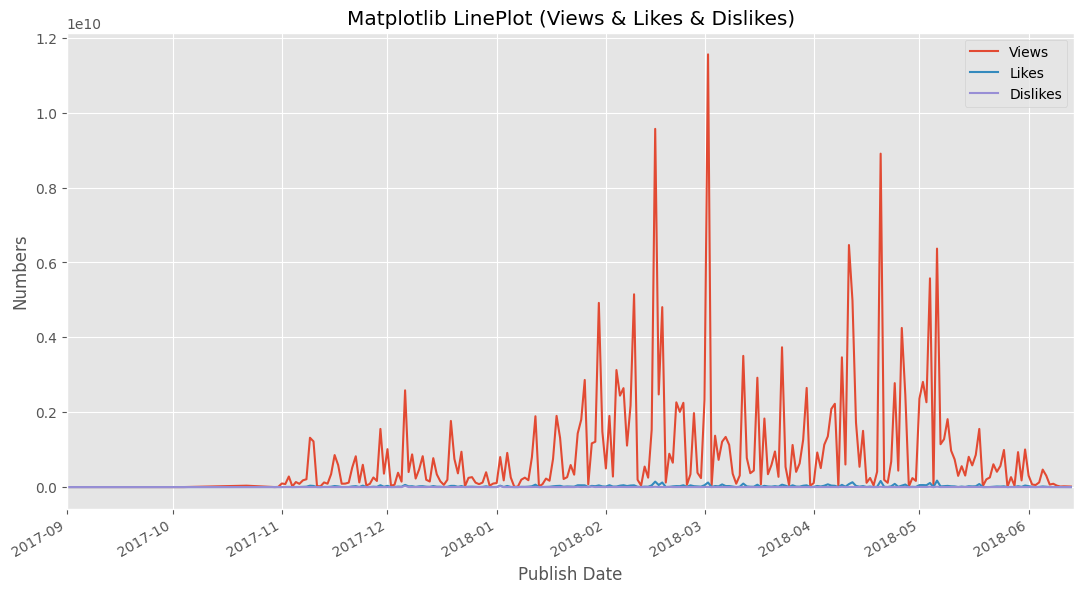

In [8]:
fig, axes = plt.subplots(1, figsize=(13,7))

# setting limits for X axis
x = [datetime.date(2017, 9, 1), datetime.date(2018, 6, 14)]

# plotting Series
views_.plot(ax=axes, xlim=(x[0],x[1]), label='Views')
likes_.plot(ax=axes, xlim=(x[0],x[1]), label='Likes')
dislikes_.plot(ax=axes, xlim=(x[0],x[1]), label='Dislikes')

axes.set_title("Matplotlib LinePlot (Views & Likes & Dislikes)")
axes.set_xlabel("Publish Date")
axes.set_ylabel("Numbers")
axes.legend()

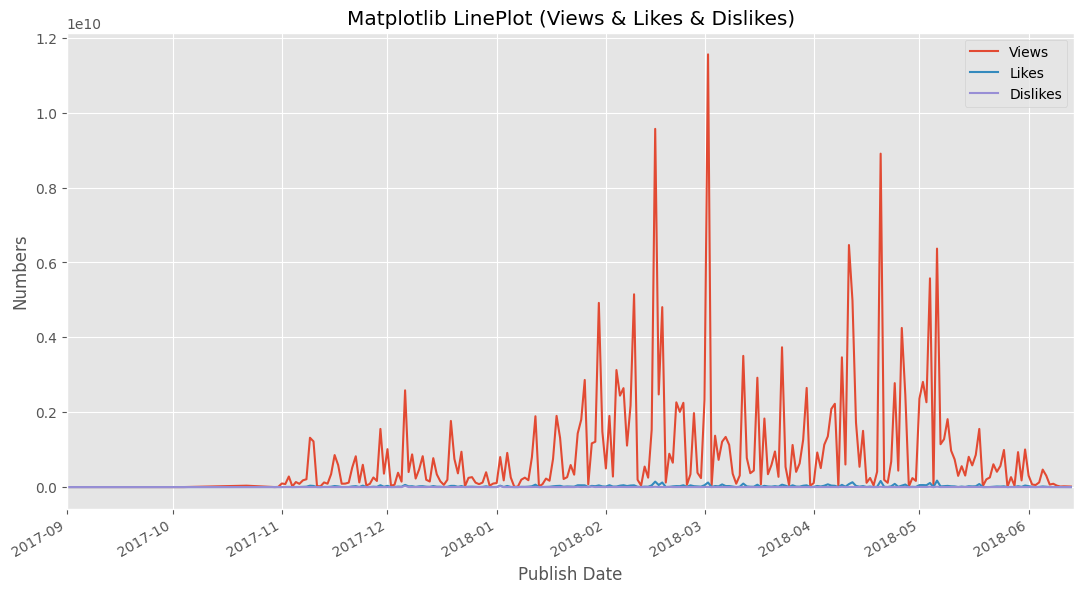

In [ ]:
# everything in one go
fig, axes = plt.subplots(1, figsize=(13,7))

# plotting data
yt_df.groupby('publish_date')['views'].sum().plot(ax=axes, label='Views')
yt_df.groupby('publish_date')['likes'].sum().plot(ax=axes, label='Likes')
yt_df.groupby('publish_date')['dislikes'].sum().plot(ax=axes, label='Dislikes')

# setting limits for X axis
axes.set_xlim(datetime.date(2017, 9, 1), datetime.date(2018, 6, 14))

# labels & title
axes.set_title("Matplotlib LinePlot (Views & Likes & Dislikes)")
axes.set_xlabel("Publish Date")
axes.set_ylabel("Numbers")
axes.legend()

##### 2) the same task, but use separate plots

Text(0, 0.5, 'Dislikes numbers')

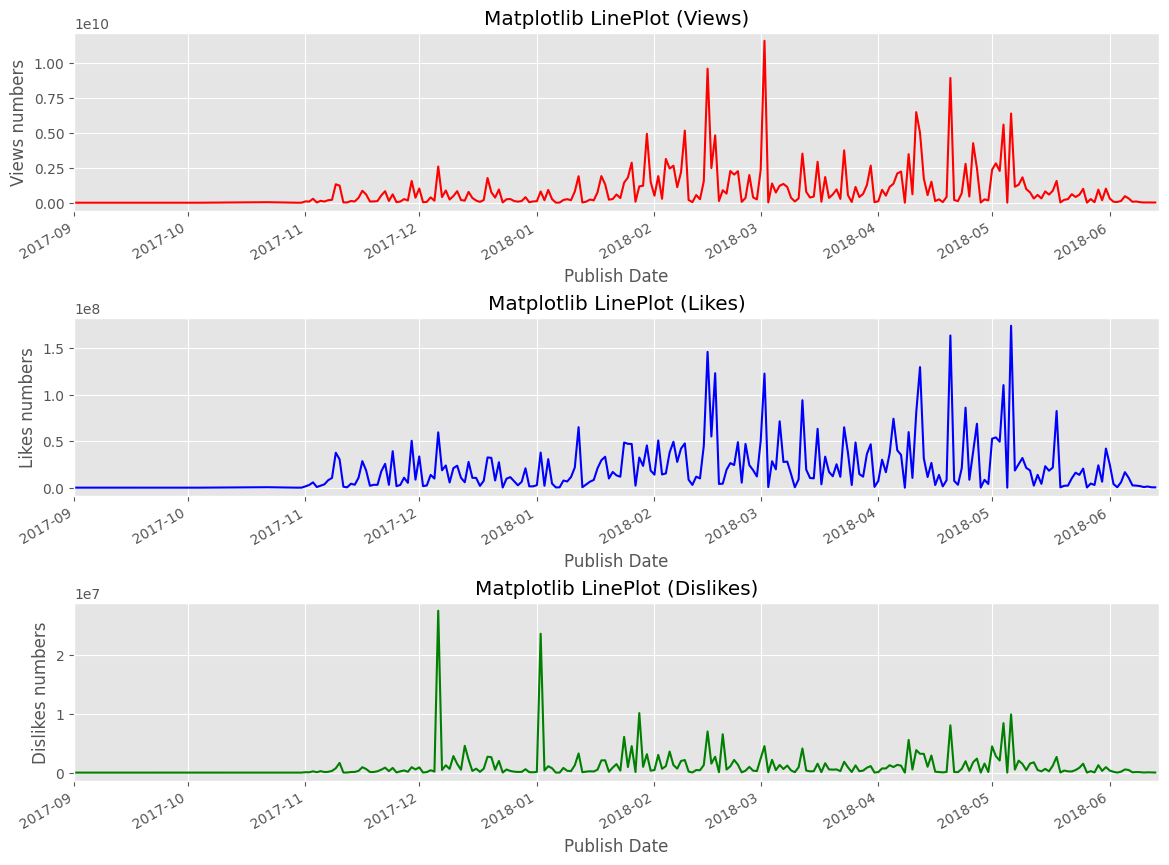

In [35]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11))

yt_df.groupby('publish_date')['views'].sum().plot(ax=ax1, color='r')
yt_df.groupby('publish_date')['likes'].sum().plot(ax=ax2, color='b')
yt_df.groupby('publish_date')['dislikes'].sum().plot(ax=ax3, color='g')

plt.subplots_adjust(wspace=.5, hspace=.6)

ax1.set_xlim(x[0],x[1])
#ax1.set_xlim([datetime.date(2007, 3, 5), datetime.date(2018, 6, 15)])
ax2.set_xlim(x[0],x[1])
ax3.set_xlim(x[0],x[1])

ax1.set_title("Matplotlib LinePlot (Views)")
ax1.set_xlabel("Publish Date")
ax1.set_ylabel("Views numbers")

ax2.set_title("Matplotlib LinePlot (Likes)")
ax2.set_xlabel("Publish Date")
ax2.set_ylabel("Likes numbers")

ax3.set_title("Matplotlib LinePlot (Dislikes)")
ax3.set_xlabel("Publish Date")
ax3.set_ylabel("Dislikes numbers")

##### 3) use **Seaborn** for the same task, limit year to 2018, by category

In [36]:
# adding categories to our data set
categories_df = pd.read_csv('../01_general_python_numpy_pandas/data/category_id.csv')
categories_df.head()

,category_id,title
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


In [37]:
yt_df = pd.merge(yt_df, categories_df, on='category_id', suffixes=(None,'_category'))
yt_df.head()

,video_id,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,description,publish_date,title_category
0,Jw1Y-zhQURU,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26.0,2017-11-10 07:38:29+00:00,"christmas|""john lewis christmas""|""john lewis""|...",7224515.0,55681.0,10247.0,9479.0,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,Click here to continue the story and make your...,2017-11-10,Howto & Style
1,3s1rvMFUweQ,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24.0,2017-11-12 06:24:44+00:00,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632.0,25561.0,2294.0,2757.0,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,Musical guest Taylor Swift performs …Ready for...,2017-11-12,Entertainment
2,n1WpP7iowLc,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10.0,2017-11-10 17:00:03+00:00,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579.0,787420.0,43420.0,125882.0,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,Eminem's new track Walk on Water ft. Beyoncé i...,2017-11-10,Music
3,PUTEiSjKwJU,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17.0,2017-11-13 02:30:38+00:00,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833.0,193.0,12.0,37.0,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,Salford drew 4-4 against the Class of 92 and F...,2017-11-13,Sports
4,rHwDegptbI4,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25.0,2017-11-13 01:45:13+00:00,[none],9815.0,30.0,2.0,30.0,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,Dashcam captures truck's near miss with child ...,2017-11-13,News & Politics


Text(0, 0.5, 'Views numbers')

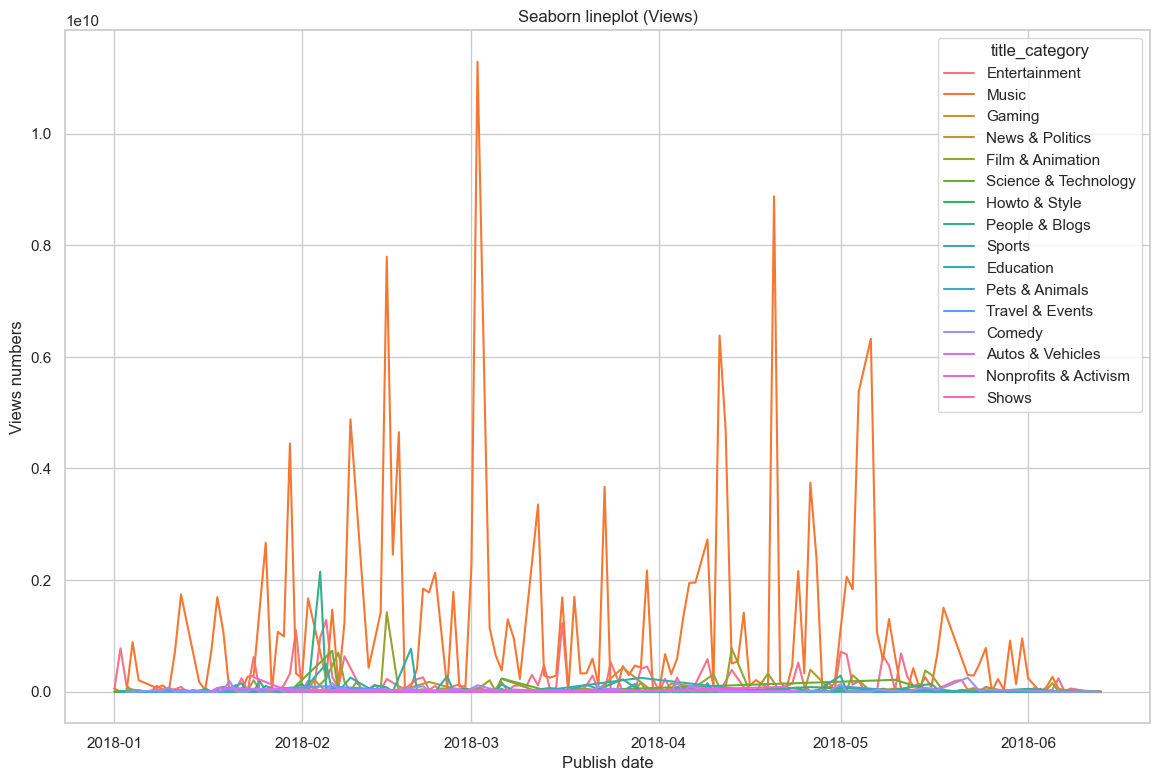

In [57]:
fig, axes = plt.subplots(1, figsize=(14, 9))

sns.lineplot(data=yt_df[yt_df['publish_date'].dt.year == 2018],
             x='publish_date', y='views', errorbar=None, estimator=np.sum,
             hue='title_category',
             ax=axes)

plt.title('Seaborn lineplot (Views)')
plt.xlabel('Publish date')
plt.ylabel('Views numbers')

##### 4) use **Seaborn** to build **barplot** for mean views by category.

In [44]:
# sns.set_theme(style="whitegrid")

Text(134.875, 0.5, 'Views mean numbers')

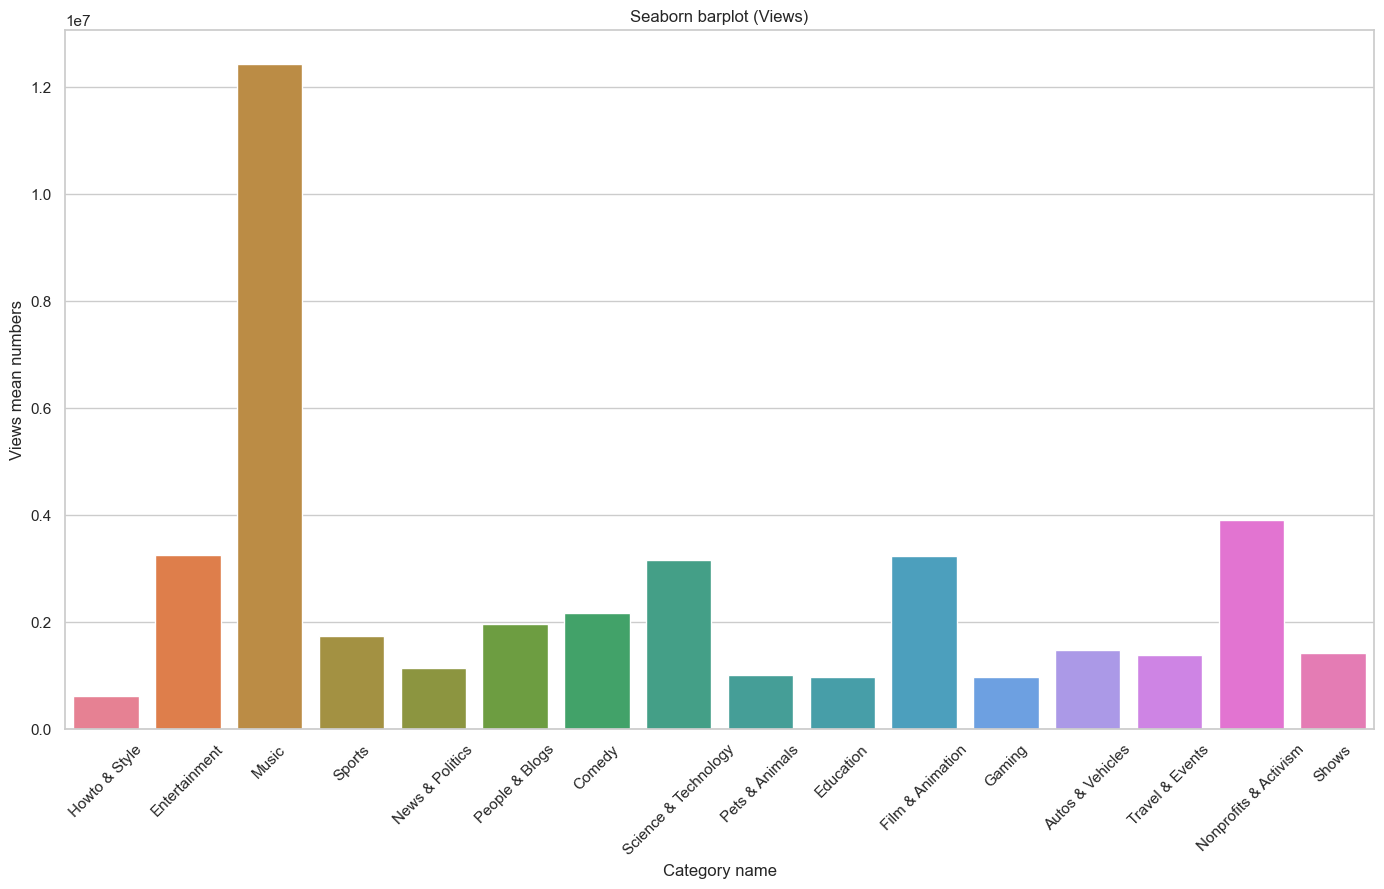

In [54]:
fig, axes = plt.subplots(1, figsize=(14,9))

sns.barplot(data=yt_df, x='title_category', y='views', 
            orient='v', errorbar=None, estimator=np.mean,
            hue='title_category',
            ax=axes)

plt.xticks(rotation=45)
plt.tight_layout()

plt.title('Seaborn barplot (Views)')
plt.xlabel('Category name')
plt.ylabel('Views mean numbers')

##### 5) build **boxplot** for "Likes by Views" metric, by category (e.g. how many likes do we get for each view, by cat?).

In [55]:
# adding likes_by_views metric to our DF
yt_df['likes_by_views'] = yt_df['likes']/yt_df['views']

Text(0.5, 1.0, 'Boxplot Likes/Views (by Category Name)')

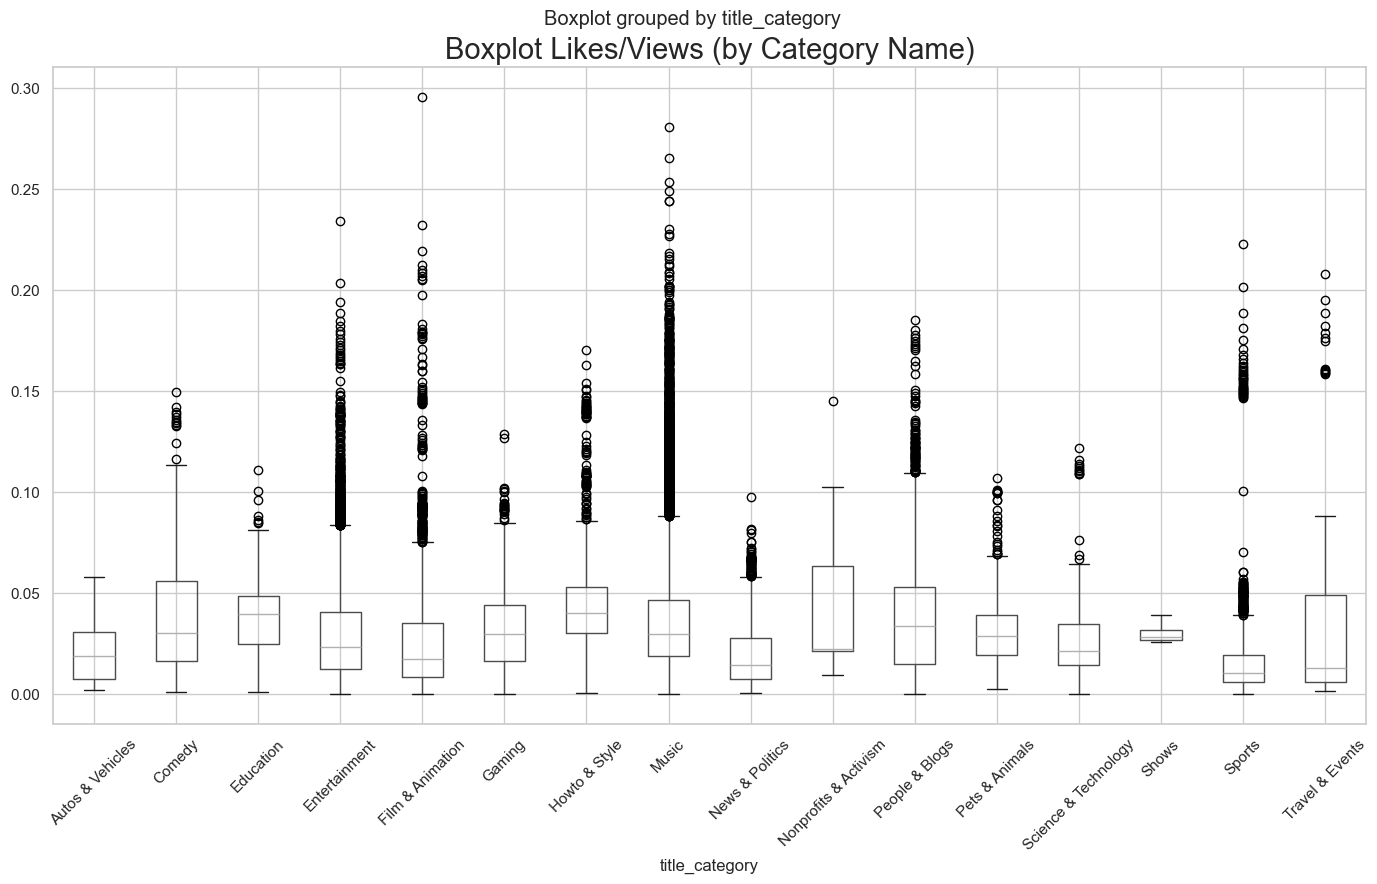

In [56]:
fig, axes = plt.subplots(1, 1, figsize=(14, 9))

yt_df.boxplot(column='likes_by_views', by='title_category', ax=axes)

plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Boxplot Likes/Views (by Category Name)', fontdict={'size':21})

Text(0.5, 1.0, 'Boxplot Likes/Views (by Category Name)')

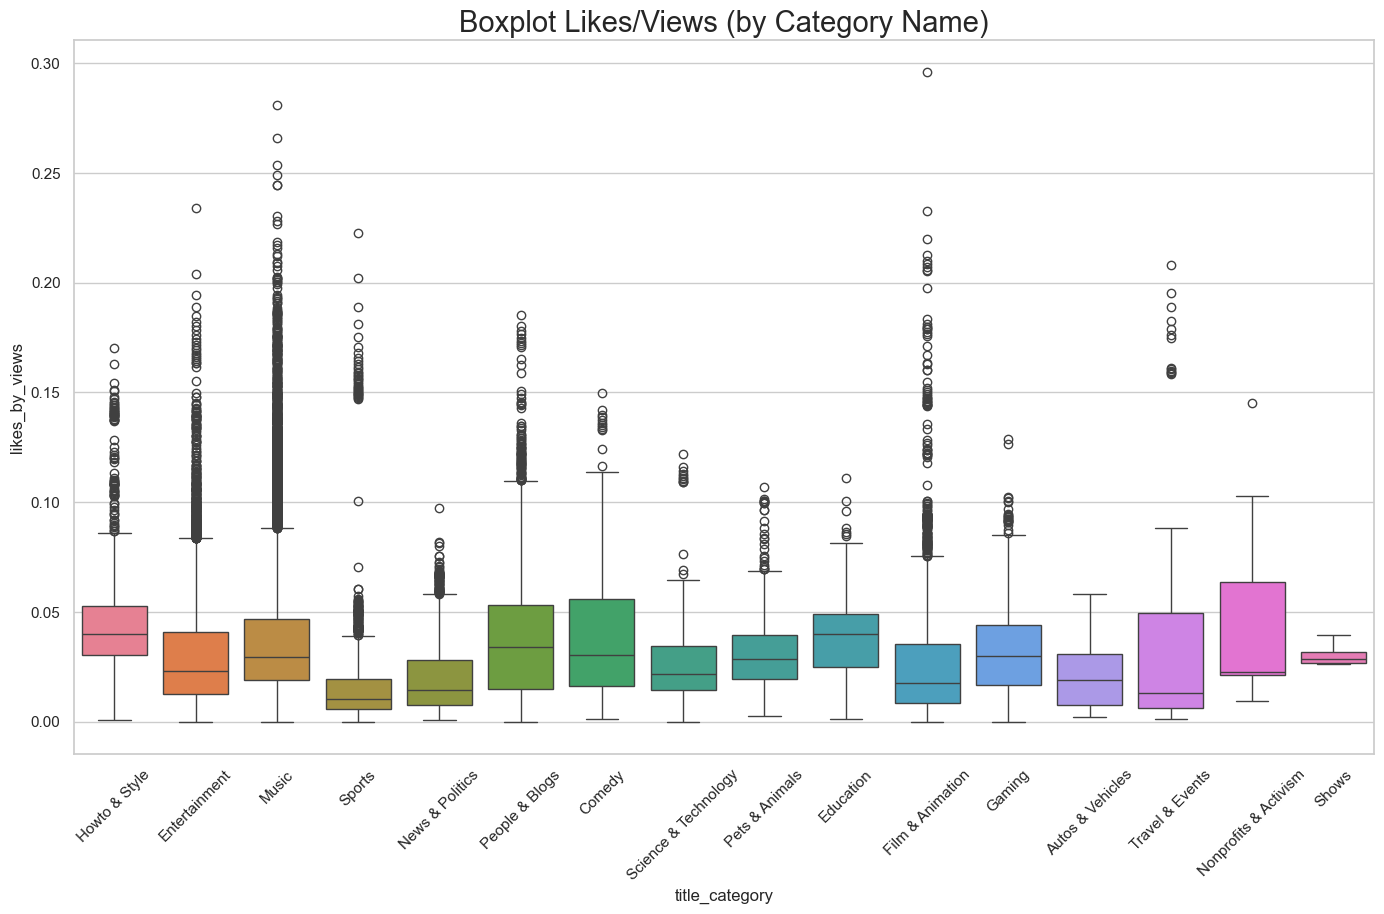

In [60]:
# the same with Seaborn
fig, axes = plt.subplots(1, 1, figsize=(14, 9))

sns.boxplot(data=yt_df,
            x="title_category", 
            y="likes_by_views",
            hue='title_category',
            ax=axes)

plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Boxplot Likes/Views (by Category Name)', fontdict={'size':21})